### Healthcare Patient Analytics

### Setup and Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
df = pd.read_csv('diabetic_data.csv')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
print(df.head())

Rows: 101,766 | Columns: 50
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No 

### Data Cleaning & EDA

In [2]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Check missing values
missing = (df.isnull().sum() / len(df) * 100).round(1)
print(missing[missing > 0].sort_values(ascending=False))

# Drop high-missing columns
df.drop(columns=['weight', 'payer_code',
                 'medical_specialty'], inplace=True)

# Drop duplicates by patient
df.drop_duplicates(subset='patient_nbr', inplace=True)

# Simplify readmission target
df['readmitted_binary'] = (
    df['readmitted'] == '<30').astype(int)

print(f'Clean rows: {len(df):,}')
print(f'\nReadmission rate: '
      f'{df["readmitted_binary"].mean()*100:.1f}%')

weight               96.9
max_glu_serum        94.7
A1Cresult            83.3
medical_specialty    49.1
payer_code           39.6
race                  2.2
diag_3                1.4
diag_2                0.4
dtype: float64
Clean rows: 71,518

Readmission rate: 8.8%


### Key EDA charts

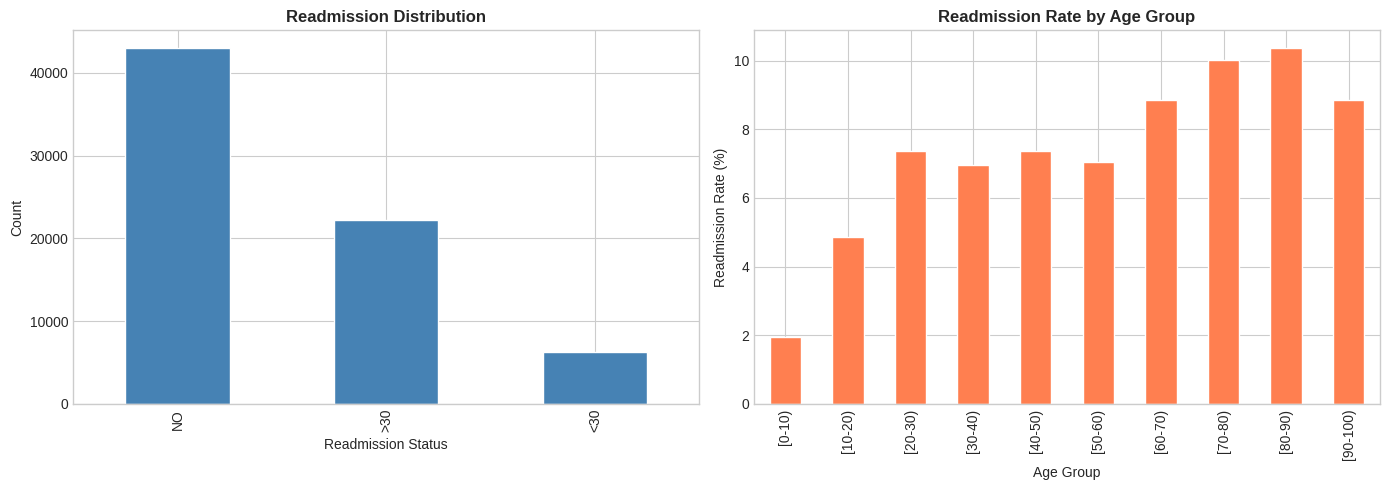

In [3]:
# Readmission distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Readmission counts
df['readmitted'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue',
    edgecolor='white')
axes[0].set_title('Readmission Distribution',
                  fontweight='bold')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Count')

# Chart 2 — Age vs readmission
age_readmit = df.groupby('age')['readmitted_binary']\
               .mean() * 100
age_readmit.plot(kind='bar', ax=axes[1],
                 color='coral', edgecolor='white')
axes[1].set_title('Readmission Rate by Age Group',
                  fontweight='bold')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.savefig('fig01_readmission_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Patient Demographics Analysis

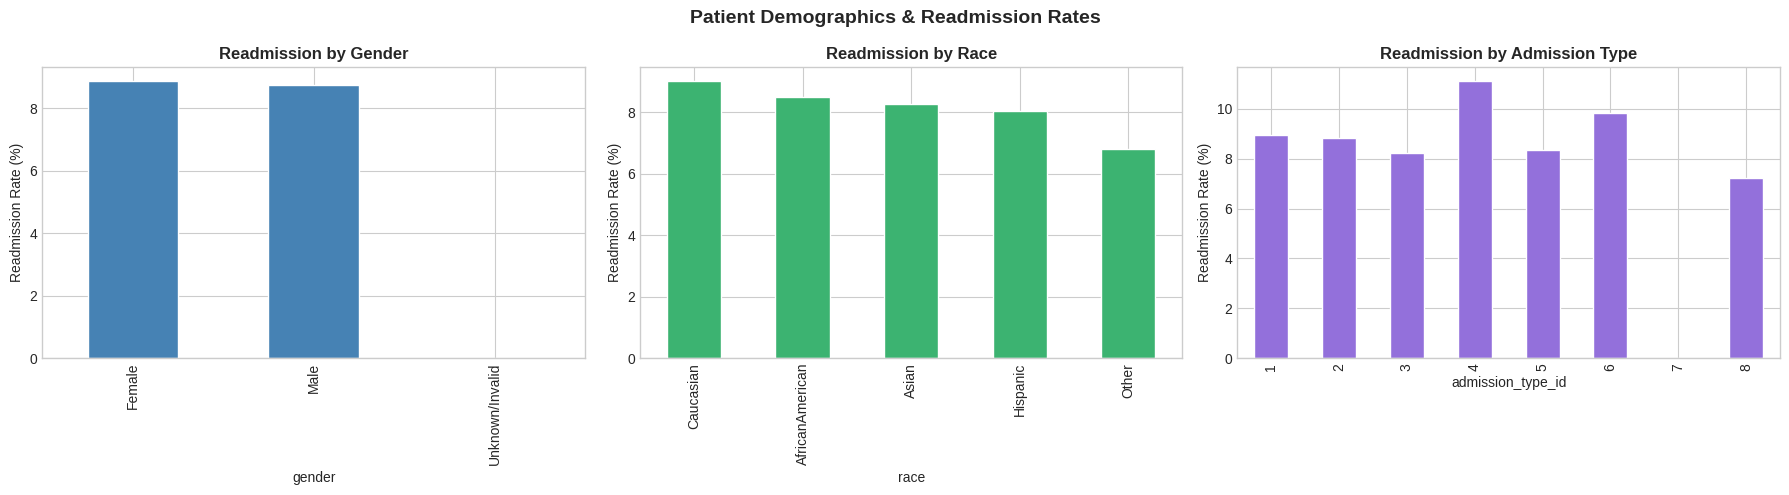

In [4]:
# Gender analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender
gender_rates = df.groupby('gender')['readmitted_binary']\
                 .mean() * 100
gender_rates.plot(kind='bar', ax=axes[0],
                  color='steelblue', edgecolor='white')
axes[0].set_title('Readmission by Gender',
                  fontweight='bold')
axes[0].set_ylabel('Readmission Rate (%)')

# Race
race_rates = df.groupby('race')['readmitted_binary']\
               .mean() * 100
race_rates.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1],
    color='mediumseagreen', edgecolor='white')
axes[1].set_title('Readmission by Race',
                  fontweight='bold')
axes[1].set_ylabel('Readmission Rate (%)')

# Admission type
admit_rates = df.groupby('admission_type_id')\
                ['readmitted_binary'].mean() * 100
admit_rates.plot(kind='bar', ax=axes[2],
                 color='mediumpurple', edgecolor='white')
axes[2].set_title('Readmission by Admission Type',
                  fontweight='bold')
axes[2].set_ylabel('Readmission Rate (%)')

plt.suptitle('Patient Demographics & Readmission Rates',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig02_demographics.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Clinical Factors Analysis

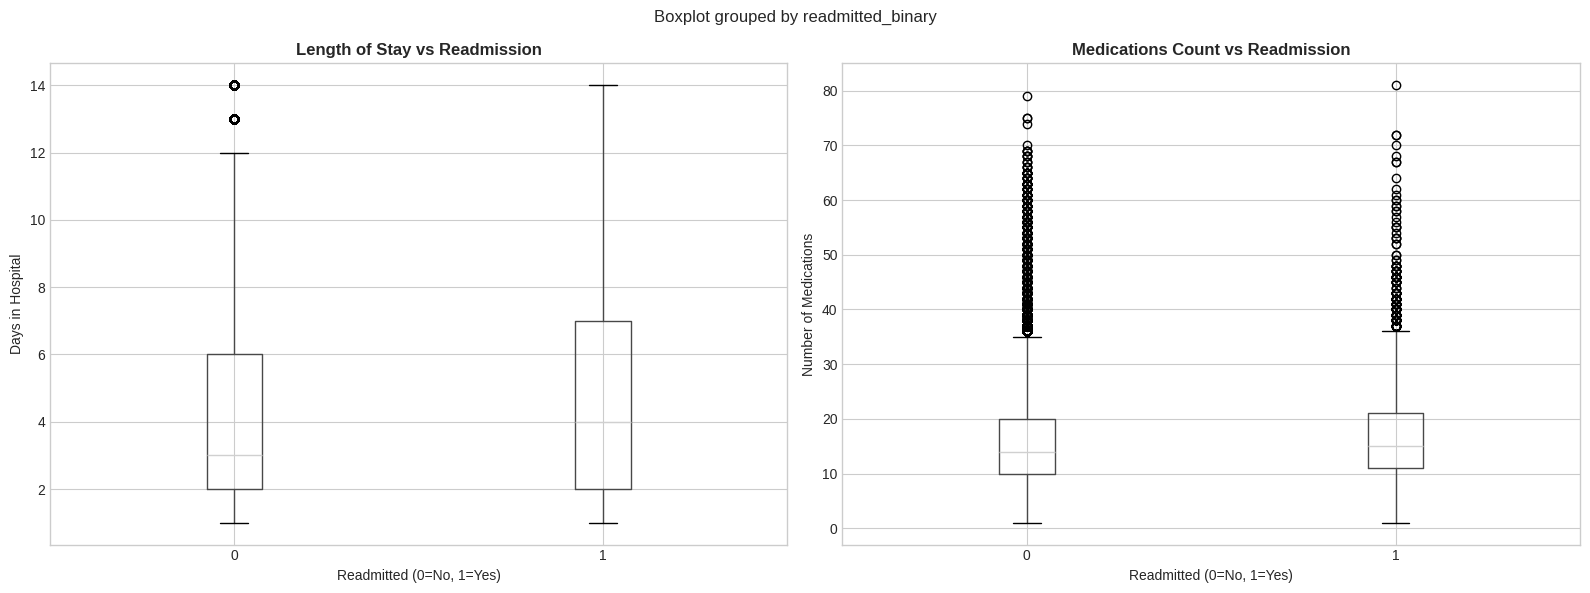

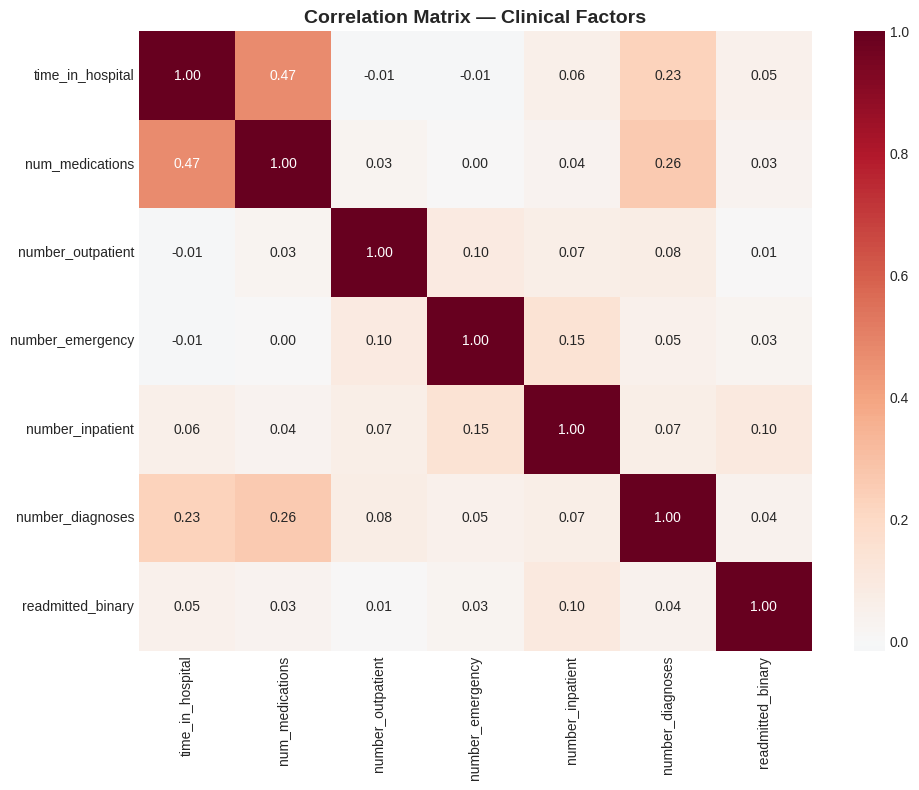

In [5]:
# Length of stay vs readmission
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Time in hospital
df.boxplot(column='time_in_hospital',
           by='readmitted_binary', ax=axes[0])
axes[0].set_title('Length of Stay vs Readmission',
                  fontweight='bold')
axes[0].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[0].set_ylabel('Days in Hospital')

# Number of medications
df.boxplot(column='num_medications',
           by='readmitted_binary', ax=axes[1])
axes[1].set_title('Medications Count vs Readmission',
                  fontweight='bold')
axes[1].set_xlabel('Readmitted (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Medications')

plt.tight_layout()
plt.savefig('fig03_clinical_factors.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
numeric_cols = ['time_in_hospital', 'num_medications',
                'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses',
                'readmitted_binary']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax)
plt.title('Correlation Matrix — Clinical Factors',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Machine Learning Model

=== MODEL COMPARISON ===
Logistic Regression AUC: 0.5916
Random Forest AUC:       0.5654

Random Forest Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     13140
           1       0.11      0.02      0.03      1164

    accuracy                           0.91     14304
   macro avg       0.51      0.50      0.49     14304
weighted avg       0.85      0.91      0.88     14304



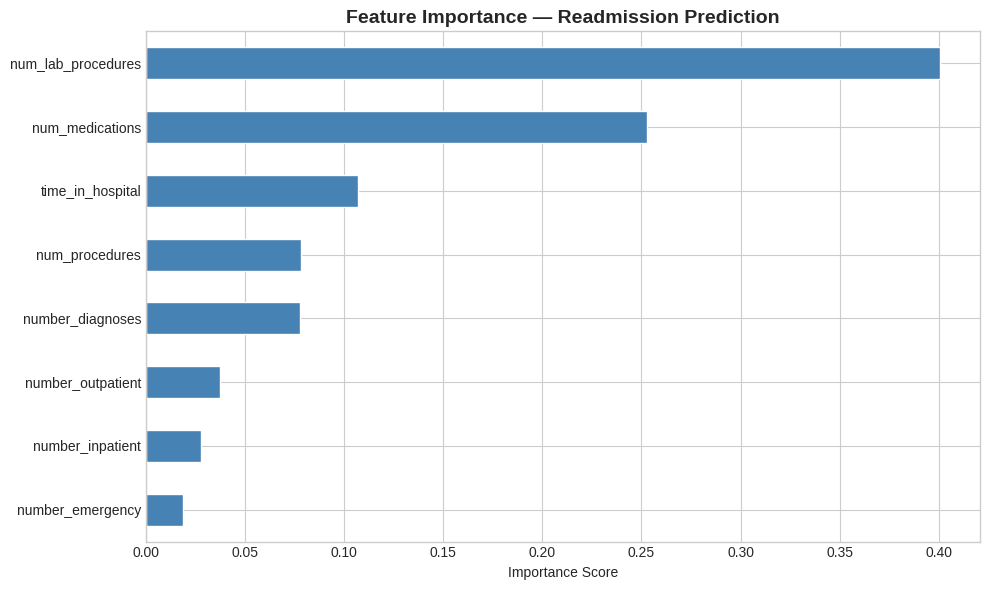

Clean data saved for Tableau and Power BI!


In [6]:
# Prepare features
feature_cols = ['time_in_hospital', 'num_medications',
                'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses',
                'num_procedures', 'num_lab_procedures']

X = df[feature_cols].fillna(0)
y = df['readmitted_binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_auc  = roc_auc_score(y_test, lr.predict_proba(
    X_test)[:,1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100,
                             random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_auc  = roc_auc_score(y_test, rf.predict_proba(
    X_test)[:,1])

print('=== MODEL COMPARISON ===')
print(f'Logistic Regression AUC: {lr_auc:.4f}')
print(f'Random Forest AUC:       {rf_auc:.4f}')
print('\nRandom Forest Report:')
print(classification_report(y_test, rf_pred))

# Feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax,
                color='steelblue', edgecolor='white')
plt.title('Feature Importance — Readmission Prediction',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig05_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save clean data for Tableau and Power BI
df.to_csv('healthcare_clean.csv', index=False)
print('Clean data saved for Tableau and Power BI!')